In [3]:
import pandas as pd
from madrid_rental.database.connection import get_engine

In [4]:
engine = get_engine()

query = """
    SELECT a.precio, a.superficie, a.habitaciones, a.banos, b.nombre AS barrio
    FROM anuncios a
    JOIN barrios b ON a.barrio_id = b.id
"""

df = pd.read_sql(query, engine)
df.head()

,precio,superficie,habitaciones,banos,barrio
0,2317.06,131.0,3,1,Arganzuela
1,517.98,40.0,2,1,Usera
2,601.34,55.0,1,1,Carabanchel
3,734.11,60.0,2,3,Vallecas
4,1365.49,80.0,2,3,Arganzuela


In [5]:
df_modelo = pd.get_dummies(df, columns=["barrio"])
df_modelo.head()

,precio,superficie,habitaciones,banos,barrio_Arganzuela,barrio_Carabanchel,barrio_Centro,barrio_Chamartín,barrio_Chamberí,barrio_Retiro,barrio_Salamanca,barrio_Tetuán,barrio_Usera,barrio_Vallecas
0,2317.06,131.0,3,1,True,False,False,False,False,False,False,False,False,False
1,517.98,40.0,2,1,False,False,False,False,False,False,False,False,True,False
2,601.34,55.0,1,1,False,True,False,False,False,False,False,False,False,False
3,734.11,60.0,2,3,False,False,False,False,False,False,False,False,False,True
4,1365.49,80.0,2,3,True,False,False,False,False,False,False,False,False,False


In [6]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   precio              1000 non-null   float64
 1   superficie          1000 non-null   float64
 2   habitaciones        1000 non-null   int64  
 3   banos               1000 non-null   int64  
 4   barrio_Arganzuela   1000 non-null   bool   
 5   barrio_Carabanchel  1000 non-null   bool   
 6   barrio_Centro       1000 non-null   bool   
 7   barrio_Chamartín    1000 non-null   bool   
 8   barrio_Chamberí     1000 non-null   bool   
 9   barrio_Retiro       1000 non-null   bool   
 10  barrio_Salamanca    1000 non-null   bool   
 11  barrio_Tetuán       1000 non-null   bool   
 12  barrio_Usera        1000 non-null   bool   
 13  barrio_Vallecas     1000 non-null   bool   
dtypes: bool(10), float64(2), int64(2)
memory usage: 41.1 KB


In [7]:
y = df_modelo["precio"]
X = df_modelo.drop(columns=["precio"])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

Train: 800
Test: 200


In [9]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 16.08, 1.29, -3.44,...,-134.38,-494.01,-586.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['superficie','habitaciones','banos',...,'barrio_Tetuán','barrio_Usera', 'barrio_Vallecas']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr: .2f} €")
print(f"R2: {r2_lr: .3f}")

MAE:  212.97 €
R2:  0.924


In [11]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test,y_pred_rf)

print(f"MAE: {mae_rf: .2f} €")
print(f"R2: {r2_rf: .3f}")

MAE:  172.50 €
R2:  0.944


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100,150,200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Mejores parámetros:", grid.best_params_)
print(f"Mejor R² (validación cruzada): {grid.best_score_:.3f}")

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 150}
Mejor R² (validación cruzada): 0.940


In [14]:
mejor_rf = grid.best_estimator_

y_pred_mejor = mejor_rf.predict(X_test)

mae_mejor = mean_absolute_error(y_test, y_pred_mejor)
r2_mejor = r2_score(y_test, y_pred_mejor)

print(f"MAE: {mae_mejor:.2f} €")
print(f"R2: {r2_mejor:.3f}")

MAE: 169.34 €
R2: 0.947


In [15]:
importancias = pd.Series(
    mejor_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias

superficie            0.772580
barrio_Salamanca      0.069877
barrio_Carabanchel    0.038450
barrio_Vallecas       0.036425
barrio_Usera          0.030709
barrio_Chamberí       0.013366
barrio_Tetuán         0.008724
barrio_Centro         0.007338
barrio_Retiro         0.007106
barrio_Arganzuela     0.004721
habitaciones          0.004557
banos                 0.003655
barrio_Chamartín      0.002491
dtype: float64

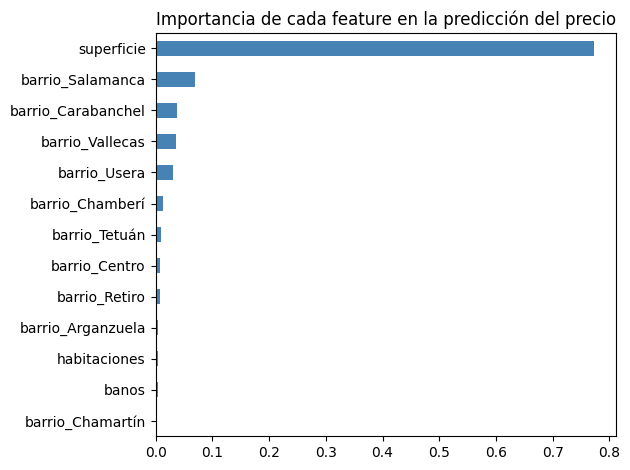

In [19]:
import matplotlib.pyplot as plt

importancias.plot(kind="barh", color="steelblue")
plt.title("Importancia de cada feature en la predicción del precio")
plt.gca().invert_yaxis()    # Invierte el eje Y para que la feature más importante quede arriba
                            # (en barh, el primer elemento se dibuja abajo por defecto)
plt.tight_layout()
plt.show()

In [20]:
resultados = X_test.copy()
resultados["precio_real"] = y_test
resultados["precio_predicho"] = mejor_rf.predict(X_test)
resultados["diferencia"] = resultados["precio_real"] - resultados["precio_predicho"]

In [21]:
# Ordenar de más chollo (diferencia más negativa) a menos
chollos = resultados.sort_values("diferencia")

# Mostrar los 10 mayores chollos
chollos[["precio_real", "precio_predicho", "diferencia"]].head(10)

,precio_real,precio_predicho,diferencia
998,3755.52,4770.804633,-1015.284633
198,2025.00,2516.296750,-491.296750
299,3615.33,4047.386351,-432.056351
559,2544.13,2967.135041,-423.005041
643,1625.49,2004.593136,-379.103136
692,1394.50,1752.867692,-358.367692
883,1624.04,1963.312781,-339.272781
802,3587.99,3925.539192,-337.549192
259,2189.45,2525.045235,-335.595235
289,1561.83,1884.827030,-322.997030
